In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import LabelEncoder

# Part 1: Understanding the Dataset

In [ ]:
df = pd.read_csv("insurance.csv")

In [ ]:
df.shape

(1338, 7)

In [ ]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')

In [ ]:
df.head(10)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


In [ ]:
df.info

<bound method DataFrame.info of       age     sex     bmi  children smoker     region      charges
0      19  female  27.900         0    yes  southwest  16884.92400
1      18    male  33.770         1     no  southeast   1725.55230
2      28    male  33.000         3     no  southeast   4449.46200
3      33    male  22.705         0     no  northwest  21984.47061
4      32    male  28.880         0     no  northwest   3866.85520
...   ...     ...     ...       ...    ...        ...          ...
1333   50    male  30.970         3     no  northwest  10600.54830
1334   18  female  31.920         0     no  northeast   2205.98080
1335   18  female  36.850         0     no  southeast   1629.83350
1336   21  female  25.800         0     no  southwest   2007.94500
1337   61  female  29.070         0    yes  northwest  29141.36030

[1338 rows x 7 columns]>

In [ ]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [ ]:
df.duplicated().sum()

np.int64(1)

In [ ]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Observations 1
1) The Dataset does not consist any null value.
2) The Dataset does not contain any duplicate values.
3) The dataset consits of 7 columsn - 
        4 - continuous numerical data ['age', 'bmi', 'children', 'charges',]
        3 - categorical data ['sex', 'smoker', 'region']
4) Charges are certainly skewed.

-------------------------------------------------------------------------------------------------------------------------------------------

# Part 2: Exploratory Data Analysis (EDA)

Text(0.5, 1.0, 'Charges Histogram')

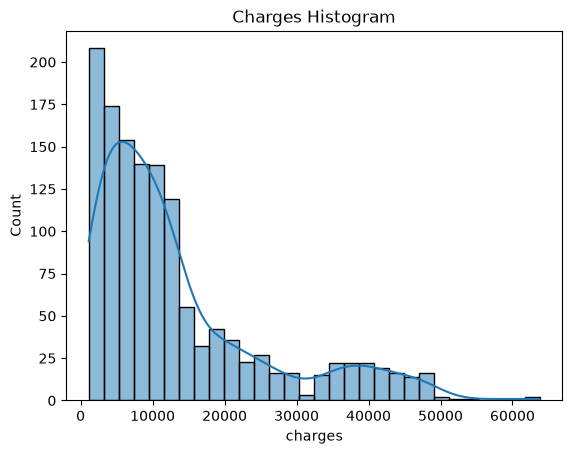

In [ ]:
#Charges_Hisplot for skewness
sns.histplot(data=df, x="charges", kde=True)
plt.title("Charges Histogram")

<Axes: xlabel='charges'>

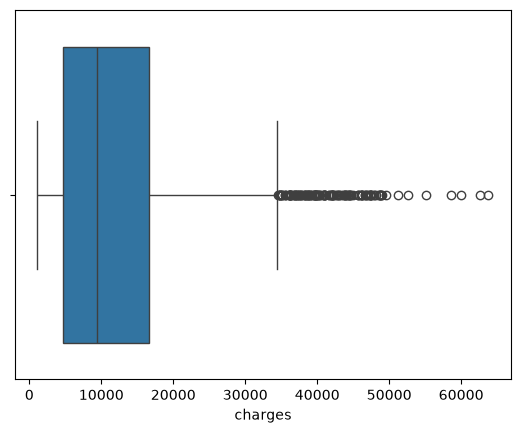

In [ ]:
#Charges boxplot for outliers
sns.boxplot(data=df, x="charges")

Relationship btw Charges and age.

<Axes: xlabel='age', ylabel='charges'>

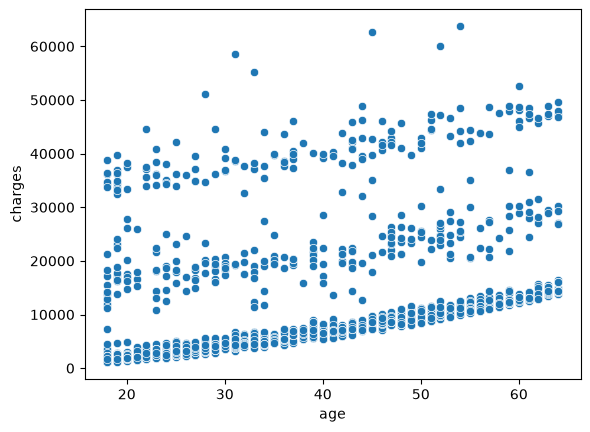

In [ ]:
# Age vs Charges
sns.scatterplot(data=df, x = "age", y = "charges")

<Axes: xlabel='age', ylabel='Count'>

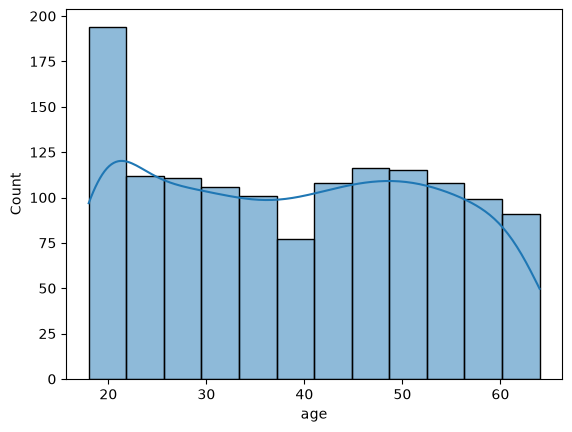

In [ ]:
# age hisplot for skewness
sns.histplot(data=df, x ="age", kde= True)

Relationship between Smoker and Charges.

<Axes: xlabel='smoker', ylabel='charges'>

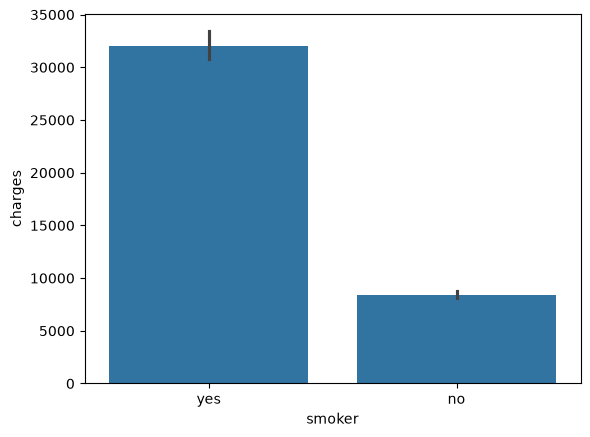

In [ ]:
# Smoker and Charges relation using barplot
sns.barplot(data=df, x="smoker", y="charges")

<Axes: xlabel='smoker', ylabel='charges'>

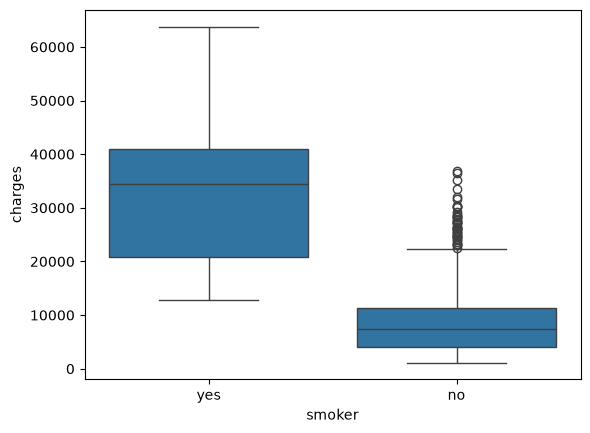

In [ ]:
# Boxplot for smoker and charges relation and outlier
sns.boxplot(df,x='smoker',y='charges')

In [ ]:
df.groupby('smoker')['charges'].describe()

,count,mean,std,min,25%,50%,75%,max
smoker,,,,,,,,
no,1064.0,8434.268298,5993.781819,1121.8739,3986.438700,7345.40530,11362.887050,36910.60803
yes,274.0,32050.231832,11541.547176,12829.4551,20826.244213,34456.34845,41019.207275,63770.42801


Does number of childrens affect the charges?

<Axes: xlabel='children', ylabel='count'>

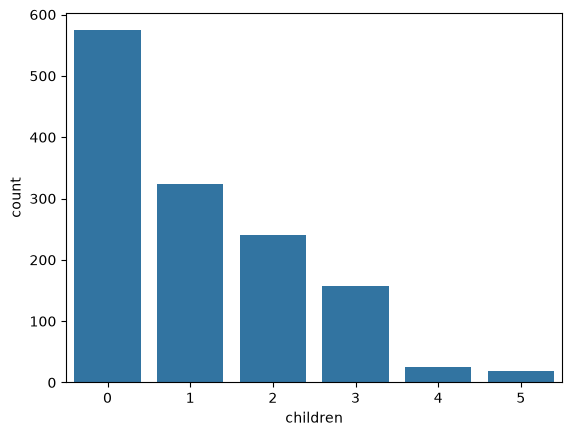

In [ ]:
# No. 0f children 
sns.countplot(data=df, x = "children")

<Axes: xlabel='children', ylabel='charges'>

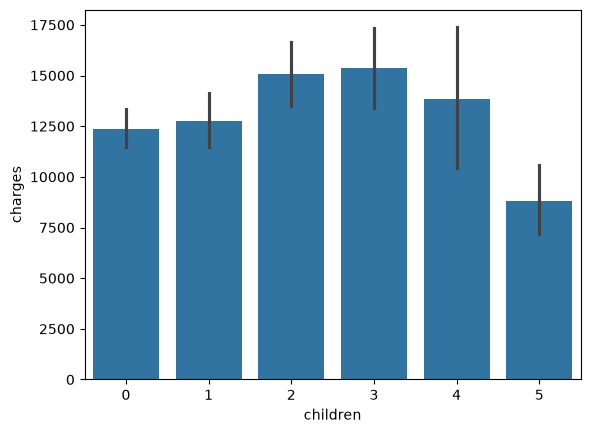

In [ ]:
sns.barplot(data=df, x = "children", y = "charges")

In [ ]:
print(df.groupby('children')['charges'].mean())

children
0    12365.975602
1    12731.171832
2    15073.563734
3    15355.318367
4    13850.656311
5     8786.035247
Name: charges, dtype: float64


Does charges depends on sex?

In [ ]:
df['sex'].value_counts(normalize=True) * 100

sex
male      50.523169
female    49.476831
Name: proportion, dtype: float64

<Axes: xlabel='sex', ylabel='count'>

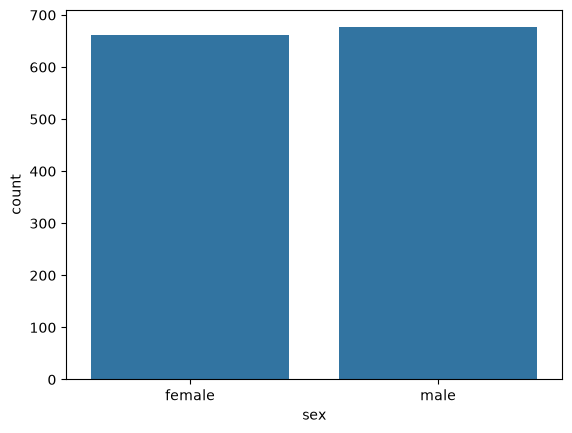

In [ ]:
# Sex distribution in dataset
sns.countplot(data=df, x="sex")

Does charges vary with region?

<Axes: xlabel='region', ylabel='charges'>

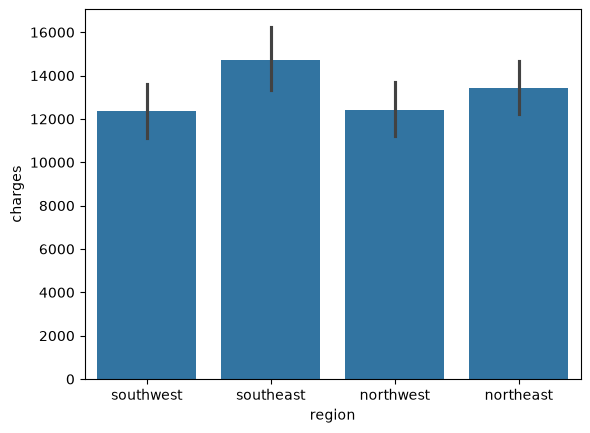

In [ ]:
# Charges and region relation
sns.barplot(data=df, x="region", y="charges")

In [ ]:
df.groupby('smoker')['charges'].mean()

smoker
no      8434.268298
yes    32050.231832
Name: charges, dtype: float64

Relationship between BMI and Charges

<Axes: xlabel='bmi', ylabel='Count'>

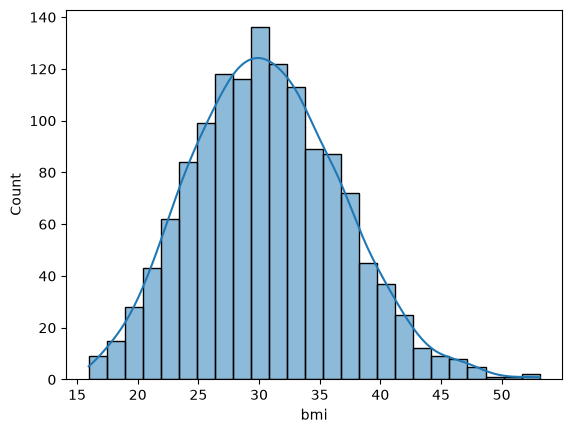

In [ ]:
# BMI skewness
sns.histplot(data=df, x ="bmi", kde= True)

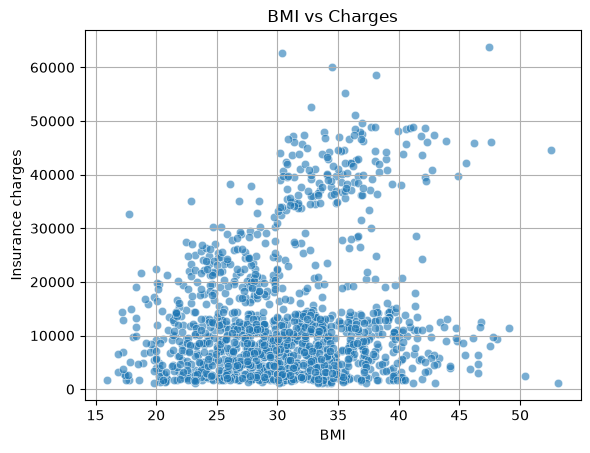

In [ ]:
sns.scatterplot(x='bmi', y='charges', data=df, alpha = 0.6)
plt.xlabel('BMI')  
plt.ylabel('Insurance charges')  
plt.title('BMI vs Charges')  
plt.grid(True)

<Axes: xlabel='bmi', ylabel='charges'>

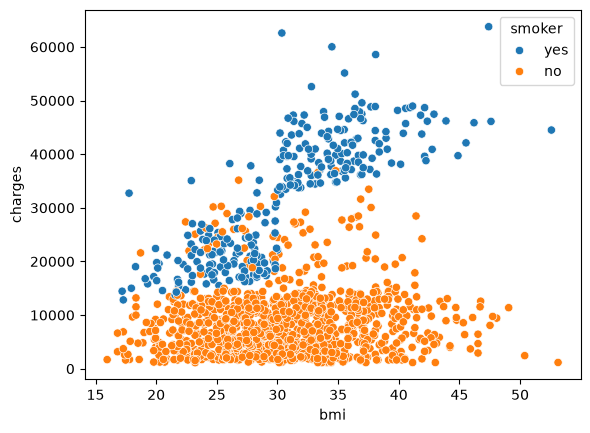

In [ ]:
sns.scatterplot(df,x='bmi',y='charges',hue='smoker')

<Axes: xlabel='children', ylabel='charges'>

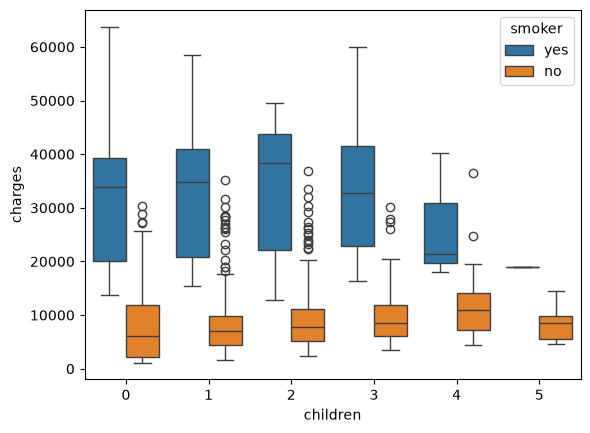

In [ ]:
sns.boxplot(df,x='children',y='charges',hue='smoker')

Text(0.5, 1.0, 'Correlation Heatmap')

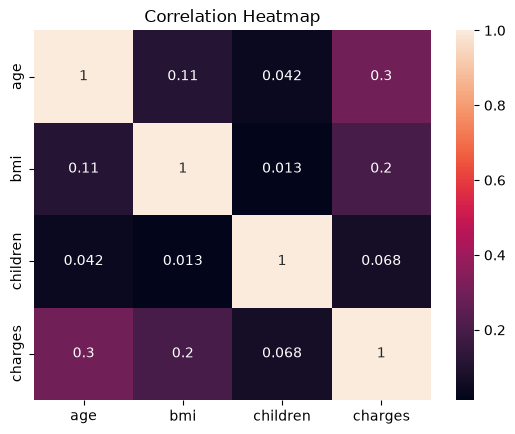

In [ ]:
sns.heatmap(df.corr(numeric_only=True),annot=True)
plt.title("Correlation Heatmap")

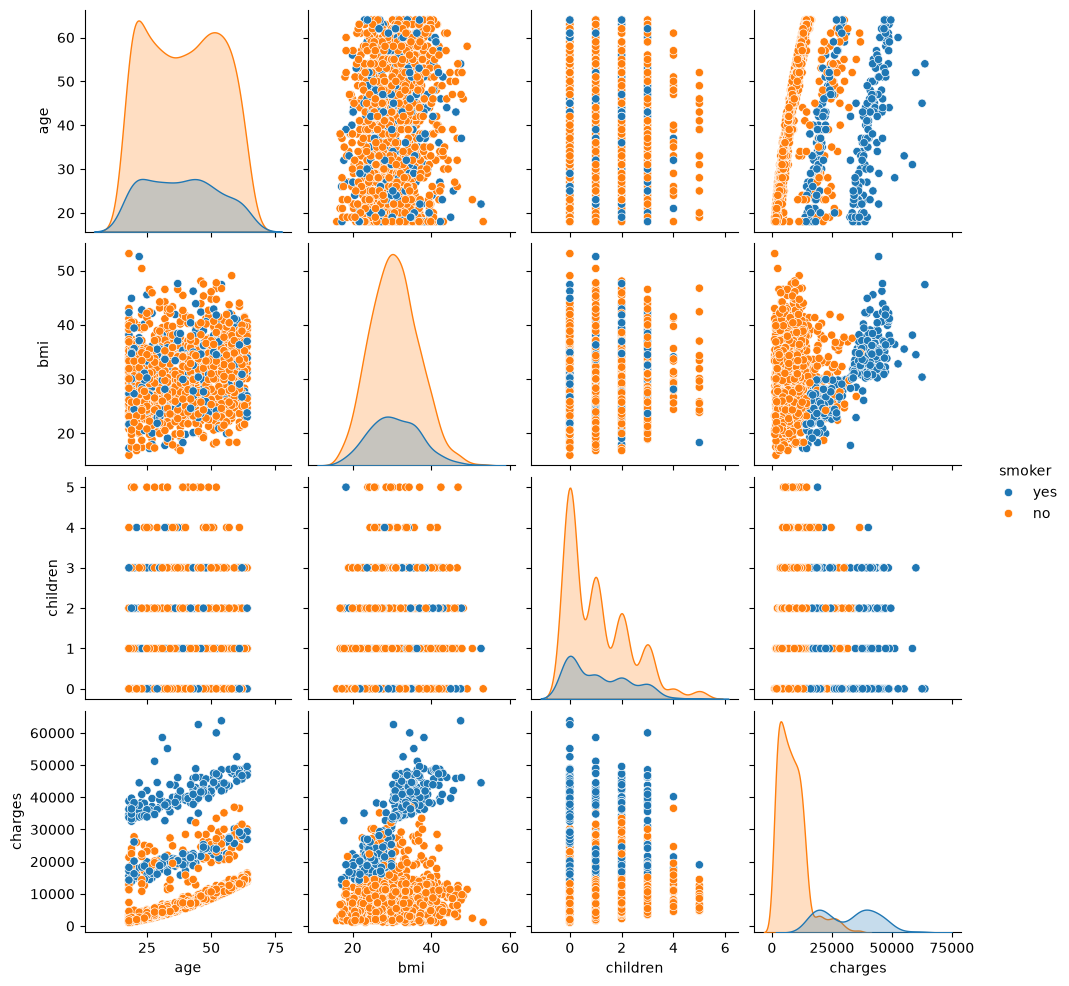

In [ ]:
sns.pairplot(data=df, hue="smoker")

observation 2

1) Charges are right skewed and their are certainly outliers - observed from boxplot and hisplot. **
2) With increase in age, charges also increases.
3) Charges significantly depends on smoker. Smoker has the highes correlation with insurance charges. **
4) Charges does not depend on sex significantly, having nearly same proportion.
5) Changes does not vary with region much.
6) Charges do depend on BMI, high BMI leads to greater charges.
7) smoker, bmi and age appear to be most useful for prediction. **

-------------------------------------------------------------------------------------------------------------------------------------------

# Part 3: Data Preprocessing

In [ ]:
dff=pd.get_dummies(df,drop_first=True)

One-Hot-encoding : is a data preprocessing technique that converts categorical variables into binary format (0s and 1s)

This step was important to convert categorical data to continuous numeric data, which can be interpreted by model. As LR model cannot interpret categorical data.

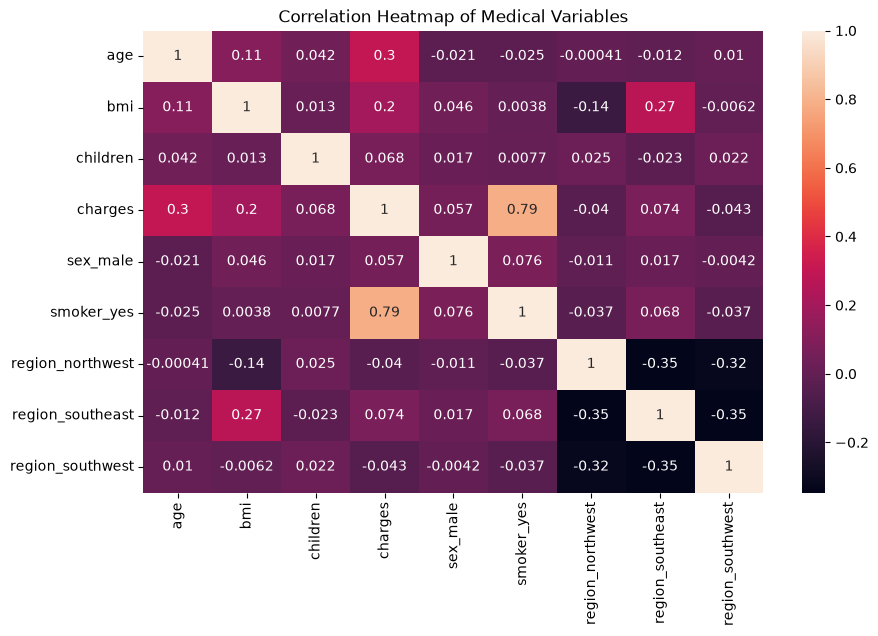

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(dff.corr(),annot=True)
plt.title('Correlation Heatmap of Medical Variables')
plt.show()

In [ ]:
dff.columns

Index(['age', 'bmi', 'children', 'charges', 'sex_male', 'smoker_yes',
       'region_northwest', 'region_southeast', 'region_southwest'],
      dtype='str')

In [ ]:
# Independent Features
X = dff[['age', 'bmi', 'children', 'sex_male', 'smoker_yes',
       'region_northwest', 'region_southeast', 'region_southwest']]

# Target
y = dff['charges']

Train_test_Split : A train-test split is a fundamental machine learning technique that divides your dataset into two subsets: a training set used to teach the model patterns, and a testing set used to evaluate its performance on unseen data.

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


StnadardScaler : to center numerical features around a mean of zero and scale them to a standard deviation of one, ensuring equal feature contribution, faster gradient descent convergence, and unbiased model regularization.

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [ ]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

-------------------------------------------------------------------------------------------------------------------------------------------

# Part 4: Linear Regression Model

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

In [ ]:
model

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [ ]:
model.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](8,)","[3614.98,2036.23, 516.89,...,-158.14,-290.16,-349.11]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.335e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(8)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](8,)","[39.95,37.74,34.68,...,31.07,29.23,18.53]"


In [ ]:
y_pred = model.predict(X_test_scaled)

y_pred


array([ 8969.55027444,  7068.74744287, 36858.41091155,  9454.67850053,
       26973.17345656, 10864.11316424,   170.28084136, 16903.45028662,
        1092.43093614, 11218.34318352, 28101.68455267,  9377.73460205,
        5263.0595179 , 38416.04221107, 40255.82339284, 37098.25353123,
       15240.39392306, 35912.88264434,  9112.52398703, 31461.92108909,
        3847.68845883, 10130.12001517,  2370.54189389,  7140.21550828,
       11301.76782638, 12961.65366224, 14509.47251876,  6159.8976107 ,
        9963.85857263,  2177.85718217,  9115.93673493, 13073.68932159,
        4561.82376202,  3408.20756033,  4459.81359745, 13032.06505076,
        1979.99357292,  8813.28303302, 33271.29124448, 32585.51583927,
        3908.76090964,  4326.10774721, 14142.81326533, 11423.45494846,
        8774.13955311, 12097.28051001,  5281.57353499,  3150.5596042 ,
       35494.46461214,  9150.1124786 , 15836.84575621,  2343.57470069,
       12364.78414194,  1482.29488266, 13389.06105161, 12573.57395972,
      

<Axes: xlabel='charges', ylabel='charges'>

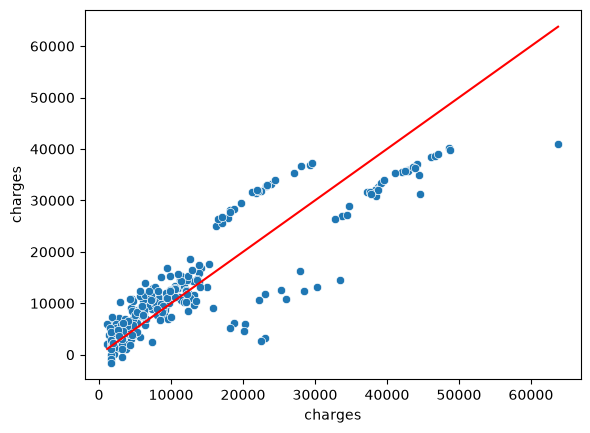

In [ ]:
sns.scatterplot(x=y_test, y=y_pred)
sns.lineplot(x=y_test, y=y_test, color='red')

In [ ]:
model.intercept_

np.float64(13346.089736364485)

In [ ]:
coefficients = pd.DataFrame({
    "feature": X.columns,
    "coefficient": model.coef_
}).sort_values(by="coefficient", key=abs, ascending=False)

coefficients

,feature,coefficient
4,smoker_yes,9558.481409
0,age,3614.975415
1,bmi,2036.228123
2,children,516.890247
7,region_southwest,-349.110678
6,region_southeast,-290.157047
5,region_northwest,-158.140981
3,sex_male,-9.293101


Interpreting coefficients:
- smoker_yes: +$9558.481409 ==> Smoking is by far the most contributing
- age: +$3614.975415 ==> older age clearly conntributes to charges
- bmi: +$2036.228123 ==> higher bmi raises charges
- children: +$516.890247 ==> having more children increases the chrges
- region: have small negative values, meaning region does not affect the charges much
- sex_male: -$-9.293101 ==> showing that practically there is no difference between male and female

-------------------------------------------------------------------------------------------------------------------------------------------

# Part 5: Model Evaluation

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, root_mean_squared_error

# Calculate the metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
print("Mean Squared Error (MSE):", mse)
print("Mean Absolute Error (MAE):", mae)
print("R-squared (R2):", r2)
print("Root Mean Squared Error (RMSE):", rmse)

Mean Squared Error (MSE): 33596915.85136148
Mean Absolute Error (MAE): 4181.194473753652
R-squared (R2): 0.7835929767120722
Root Mean Squared Error (RMSE): 5796.284659276275


In [ ]:
n = X_test_scaled.shape[0]      # Number of samples
p = X_test_scaled.shape[1]      # Number of features

adjusted_r2 = 1 - ((1 - r2) * (n - 1)) / (n - p - 1)

print("Adjusted R-squared (R2):", adjusted_r2)

Adjusted R-squared (R2): 0.7769085898923679


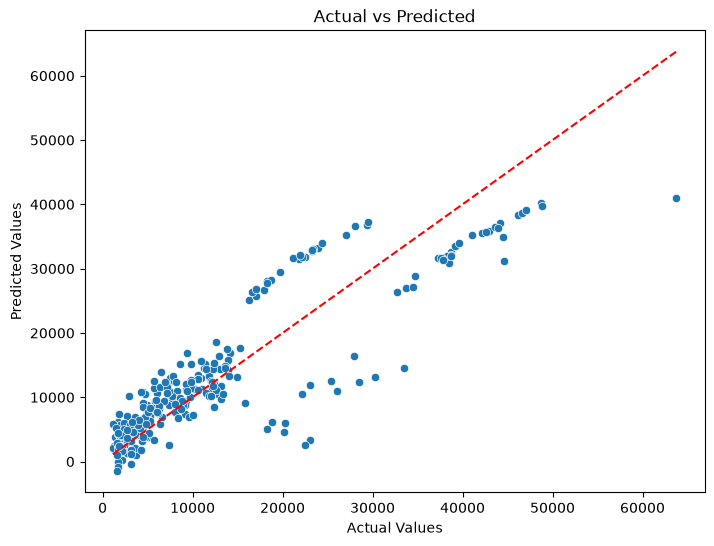

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(x=y_test, y=y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linestyle='--'
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")
plt.show()

In [ ]:
residuals = y_test - y_pred

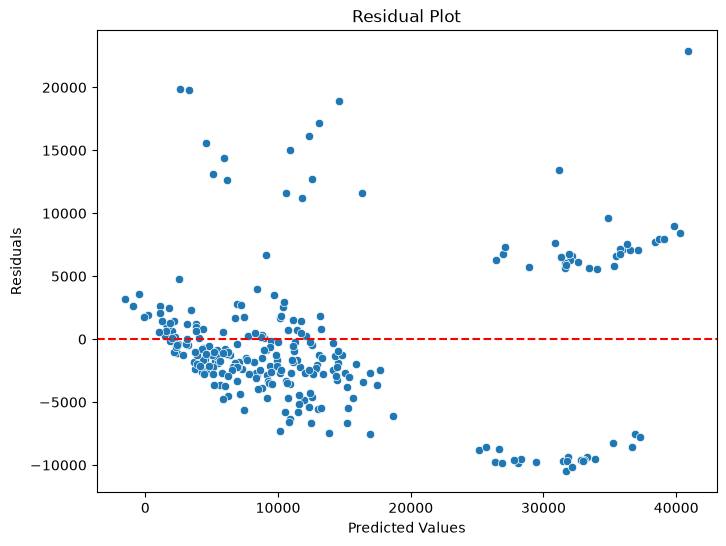

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(x=y_pred, y=residuals)

plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

1) R2 score is most suitable for regression problem. As it indicates how well the independent variables explains the variation in dataset.

-------------------------------------------------------------------------------------------------------------------------------------------

# Part 6: Model Improvement / Hyperparameter Tuning

In [ ]:
from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=1.0)

In [ ]:
ridge_model.fit(X_test_scaled, y_test)

,"alpha alpha: float or array-like of shape (n_targets,), default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.See :ref:`sphx_glr_auto_examples_linear_model_plot_ridge_coeffs.py`for an illustration of the effect of alpha on the model coefficients.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' 

In [ ]:
y_pred = ridge_model.predict(X_test_scaled)

In [ ]:
# Calculate the metrics for ridge_model
ridge_mse = mean_squared_error(y_test, y_pred)
ridge_mae = mean_absolute_error(y_test, y_pred)
ridge_r2 = r2_score(y_test, y_pred)
ridge_rmse = root_mean_squared_error(y_test, y_pred)
print("Mean Squared Error (MSE):", ridge_mse)
print("Mean Absolute Error (MAE):",ridge_mae)
print("R-squared (R2):", ridge_r2)
print("Root Mean Squared Error (RMSE):",ridge_rmse)

Mean Squared Error (MSE): 32628940.218597297
Mean Absolute Error (MAE): 3962.8182085692515
R-squared (R2): 0.7898279753717261
Root Mean Squared Error (RMSE): 5712.1747363501845


In [ ]:
n = X_test_scaled.shape[0]      # Number of samples
p = X_test_scaled.shape[1]      # Number of features

ridge_adjusted_r2 = 1 - ((1 - ridge_r2) * (n - 1)) / (n - p - 1)

print("Adjusted R-squared (R2):", ridge_adjusted_r2)

Adjusted R-squared (R2): 0.783336175383208


In [ ]:
comparison_df = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge Regression"],
    "RMSE": [rmse, ridge_mse],
    "MSE": [mse, ridge_mse],
    "MAE": [mae, ridge_mae], 
    "R2": [r2, ridge_r2],
    "Adjusted R2": [adjusted_r2, ridge_adjusted_r2]
})

comparison_df

,Model,RMSE,MSE,MAE,R2,Adjusted R2
0,Linear Regression,5.796285e+03,3.359692e+07,4181.194474,0.783593,0.776909
1,Ridge Regression,3.262894e+07,3.262894e+07,3962.818209,0.789828,0.783336


-------------------------------------------------------------------------------------------------------------------------------------------

# Part 7: Business Insights
1. Which customer segment is likely to incur the highest medical expenses?
   - Smokers, person with high BMI, Older people.

2. How does smoking affect insurance charges?
   - Smokers pay signifiacntly higher than non-smokers.

3. Should insurance companies treat smokers differently while pricing policies?
   - Yes, as smokers represents high incurance risks. 

4. Which features are the strongest predictors of insurance cost?
   - smokers, BMI and age are the strongest predictors of insurance cost.

5. Suggest strategies to reduce healthcare costs based on the analysis. 
   - Create awareness about smoking risks.
   - Promote healthy lifestyle programs. 
   - Promote preventive healthcare.
   - Encouraging events like running, marathon, cycling ets.